# Crater sharpness grading: review

Visual review of `src/trntest/crater_depth.py`/`crater_depth_batch.py`'s crater sharpness
grading -- see `docs/crater-grading.md` for the full design. Sharpness itself
(`crater_depth.sharpness_ratio`) is measured depth over Stoffler et al. 2006's reference
"fresh crater" depth for the same diameter (`crater_depth.stoffler_fresh_depth_km`) -- ~1.0 for a
crater as deep as a fresh crater of its size "should" be, well below 1.0 for a degraded one.

Two checks:
1. **Sharpness-colored crater overlay** on the same hillshade basemap
   (`dem_ortho_result.ortho`) `image_generation.ipynb`'s Phase 5B/6B use, with the Robbins
   ellipses drawn in the same sparse dashed style -- but colored by sharpness instead of one
   fixed color, so fresh/degraded craters should visibly separate by color.
2. **Diameter vs. depth 2D histogram**, with the Stoffler reference curve overlaid -- checks
   whether the measured population actually clusters around the reference curve the way the
   formula assumes, or whether it's systematically offset.

Both need depth data for this candidate's own footprint, which doesn't exist yet the first
time this notebook runs against a new candidate -- **Load the candidate** below grades just the
tiles covering it (`crater_depth_batch.grade_footprint`) and consolidates the result
(`crater_depth_batch.consolidate_graded_geopackage`) before either plot. Minimal setup, reusing
`image_generation.ipynb`'s Phase 1-2 exactly (same manifest, same `TrnTestDataSet`) but skipping
`dataset.populate()` entirely, the same way `hapke_hillshade.ipynb` does -- `entry.dem_ortho_result`
is enough; this notebook never needs the `sat_sim` render or the ISIS WAC crop either phase would
otherwise generate.

In [1]:
import geopandas
import matplotlib.colors
import matplotlib.pyplot as plt
import matplotlib.ticker
import numpy as np
import rasterio

import trntest
from trntest import crater_depth, crater_depth_batch, craters, geo_utils

images = trntest.read_manifest("dataset_manifest.csv")
session = trntest.Session()

dataset = trntest.TrnTestDataSet.create(session.config.output_dir / "trn_dataset", images, session.config)
entry = dataset[0]
dem_ortho_result = entry.dem_ortho_result

print(f"EDR product: {entry.edr_product}")
print(f"Ground footprint center (lon, lat): {entry.camera.footprint_lonlat_deg['center']}")

EDR product: M1327210646CE


Ground footprint center (lon, lat): (np.float64(169.57486295444002), np.float64(38.762076138016))


## Grade this footprint's tiles, then consolidate

`grade_footprint` only grades tiles whose nominal bounds actually touch `dem_ortho_result.ortho`'s
own footprint (typically a handful of tiles at the default 2 deg tile size, not the whole
~14,220-tile global grid) -- writes into the same per-tile CSVs a full `grade_database`/
`grade_database_via_workers` run would, so this is fully resumable/compatible with a later
whole-database run, not a separate one-off. `consolidate_graded_geopackage` then left-joins
whatever's graded so far (across *every* prior run against this cache, not just this footprint)
onto the full Robbins table and writes `sharpness` alongside it -- a snapshot, safe to re-run.

In [2]:
n_graded = crater_depth_batch.grade_footprint(dem_ortho_result.ortho, session.config)
print(f"Newly graded tiles this run: {n_graded}")

gpkg_path = crater_depth_batch.consolidate_graded_geopackage(session.config)
print(f"Consolidated graded database: {gpkg_path}")

Newly graded tiles this run: 0


Consolidated graded database: /workspace/cache/crater_depth_tiles_t2_p3_g100/robbins_with_depth.gpkg


## Query this footprint's graded craters

Same query/ellipse-construction pattern `craters.crater_overlay_layer` uses (bbox-pushdown query
via `craters.raster_bbox_deg`, then `craters._ellipse_polygon` per row against each crater's
center reprojected into the raster's own CRS) -- applied to the consolidated "Robbins + depth"
GeoPackage instead of the plain Robbins one, and keeping `depth_m`/`sharpness` as per-row
attributes rather than reducing everything to one flat overlay color. Rows with no depth grade
(not yet graded -- shouldn't happen for this footprint's own tiles right after the cell above --
or graded but excluded for not fitting its tile's padded raster) are dropped: nothing to plot or
histogram for them.

In [3]:
def graded_craters_in_view(gpkg_path, raster_path, padding_fraction=0.05):
    with rasterio.open(raster_path) as src:
        raster_crs = src.crs
    padded_bbox_deg = geo_utils.pad_bbox(craters.raster_bbox_deg(raster_path), padding_fraction)
    gdf = geopandas.read_file(gpkg_path, bbox=padded_bbox_deg)
    minlon, minlat, maxlon, maxlat = padded_bbox_deg
    gdf = gdf.cx[minlon:maxlon, minlat:maxlat]
    gdf = gdf[gdf["depth_m"].notna()].reset_index(drop=True)

    centers_in_raster_crs = gdf.to_crs(raster_crs)
    ellipses = [
        craters._ellipse_polygon(
            center.x, center.y, row["DIAM_ELLI_MAJOR_IMG"], row["DIAM_ELLI_MINOR_IMG"], row["DIAM_ELLI_ANGLE_IMG"]
        )
        for (_, row), center in zip(gdf.iterrows(), centers_in_raster_crs.geometry, strict=True)
    ]
    return geopandas.GeoDataFrame(
        {
            "CRATER_ID": gdf["CRATER_ID"],
            "diameter_km": gdf["DIAM_CIRC_IMG"],
            "major_km": gdf["DIAM_ELLI_MAJOR_IMG"],
            "depth_m": gdf["depth_m"],
            "sharpness": gdf["sharpness"],
        },
        geometry=ellipses,
        crs=raster_crs,
    )


graded_view = graded_craters_in_view(gpkg_path, dem_ortho_result.ortho)
print(f"Graded craters in view: {len(graded_view)}")

Graded craters in view: 3814


## Sharpness-colored crater overlay

Same base raster and sparse-dashed style as `image_generation.ipynb`'s Phase 5B/6B crater layer
(`linestyle=(0, (1, 6))`) -- but colored per-crater by `sharpness` (`cmap="RdYlGn"`: red = degraded,
green = fresh) instead of one fixed color. `GeoDataFrame.boundary` returns a bare `GeoSeries` (just
geometry, no attribute columns) -- rebuilt as its own `GeoDataFrame` with `sharpness` reattached so
`.plot(column="sharpness", ...)` (a `GeoDataFrame`-only feature) has something to color by; the
equivalent single-flat-color case (`plotting.OverlayLayer.plot`) never needed this since it only
ever draws one color for a whole layer. `vmin`/`vmax` are fixed, not data-derived, so color means
the same thing across different candidates/reruns -- 2.0 gives headroom above the 1.0
"exactly fresh" reference for crater-to-crater scatter (Stoffler's curve is a central
tendency fit, not an upper bound).

`MIN_MAJOR_KM` filters this panel only (`Phase 5B/6B`'s own `min_major_km` convention/name,
applied to the same `DIAM_ELLI_MAJOR_IMG`-derived column) -- the unfiltered population at this
footprint's scale (thousands of mostly-small craters) made the sparse-dashed ellipses collapse
into an unreadable cloud rather than showing individual crater shapes; the histogram below stays
unfiltered, since its whole point is the full distribution, not individually legible shapes.
`graded_craters_in_view`'s own query bbox is deliberately padded 5% beyond the raster's
footprint (a crater whose *center* sits just outside the exact frame can still overlap
it) -- so this panel's axis limits are clipped to the raster's own exact bounds
(`ax.set_xlim`/`set_ylim`) to suppress those queried-but-out-of-frame craters from the display,
rather than re-filtering the query itself.

Craters shown (major_km >= 6.0): 267 of 3814 graded


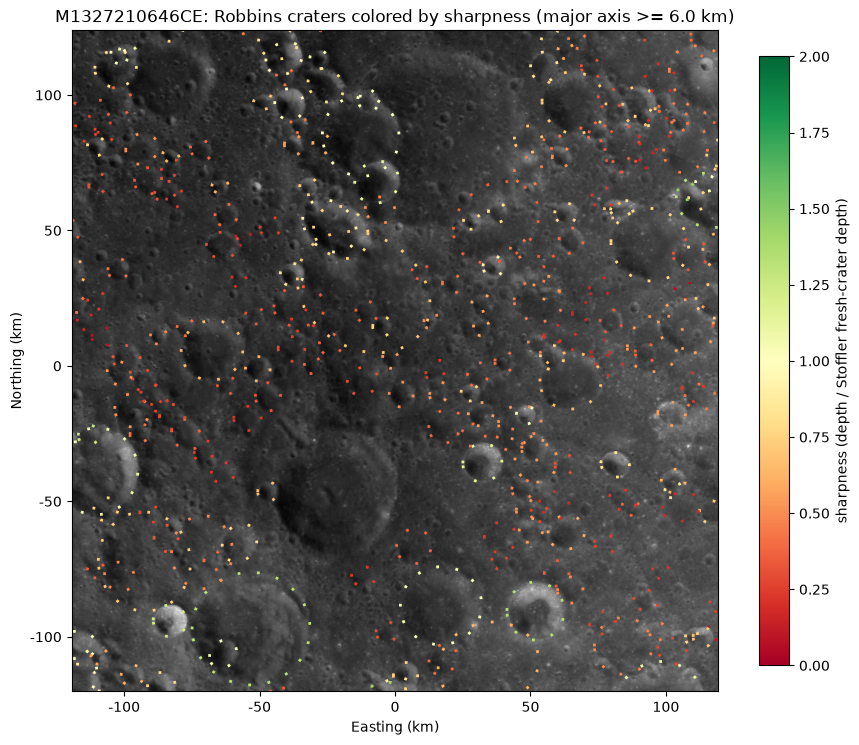

In [4]:
MIN_MAJOR_KM = 6.0
SHARPNESS_VMIN, SHARPNESS_VMAX = 0.0, 2.0

overlay_view = graded_view[graded_view["major_km"] >= MIN_MAJOR_KM]
print(f"Craters shown (major_km >= {MIN_MAJOR_KM}): {len(overlay_view)} of {len(graded_view)} graded")

boundary_gdf = geopandas.GeoDataFrame(
    {"sharpness": overlay_view["sharpness"]}, geometry=overlay_view.boundary, crs=overlay_view.crs
)

with rasterio.open(dem_ortho_result.ortho) as src:
    ortho = src.read(1)
    ortho_bounds = src.bounds

km_formatter = matplotlib.ticker.FuncFormatter(lambda value, _pos: f"{value / 1000.0:.0f}")

fig, ax = plt.subplots(figsize=(9, 9))
ax.imshow(ortho, cmap="gray", extent=(ortho_bounds.left, ortho_bounds.right, ortho_bounds.bottom, ortho_bounds.top))
boundary_gdf.plot(
    ax=ax,
    column="sharpness",
    cmap="RdYlGn",
    vmin=SHARPNESS_VMIN,
    vmax=SHARPNESS_VMAX,
    linewidth=2.0,
    linestyle=(0, (1, 6)),
    legend=True,
    legend_kwds={"label": "sharpness (depth / Stoffler fresh-crater depth)", "shrink": 0.7},
)
ax.set_xlim(ortho_bounds.left, ortho_bounds.right)
ax.set_ylim(ortho_bounds.bottom, ortho_bounds.top)
ax.xaxis.set_major_formatter(km_formatter)
ax.yaxis.set_major_formatter(km_formatter)
ax.set_title(f"{entry.edr_product}: Robbins craters colored by sharpness (major axis >= {MIN_MAJOR_KM} km)")
ax.set_xlabel("Easting (km)")
ax.set_ylabel("Northing (km)")
fig.tight_layout()

## Depth vs. diameter, against the Stoffler reference curve

2D histogram of every graded crater in view -- diameter (x) vs. measured depth (y), color =
crater count in that bin. **Both axes and the bin edges are log-spaced**, not linear -- crater
size-frequency famously follows a power law (many small craters, few large ones), and the Stoffler
reference curve itself is a power law in both its regimes, so a linear-binned view was tried first
and found unreadable: one bin near the smallest diameters/depths held the vast majority
of craters, visually swamping everything else, while the interesting structure (whether the
bulk of craters track the reference curve or deviate from it) was compressed into a sliver of the
plot. Log-log is also the standard way this kind of depth-diameter data is presented in the
planetary science literature, not just a fix for this one plot's own axis range. Log-scaled color
(`LogNorm`) for the same underlying reason -- count-per-bin is itself skewed. Depths must be
positive to take a log; any non-positive `depth_m` (possible in principle for a heavily degraded/
noisy measurement) is dropped and counted, not silently discarded.

This is one candidate's own local footprint, not the whole database -- a small sample, illustrative
rather than a statistically robust population-level check.

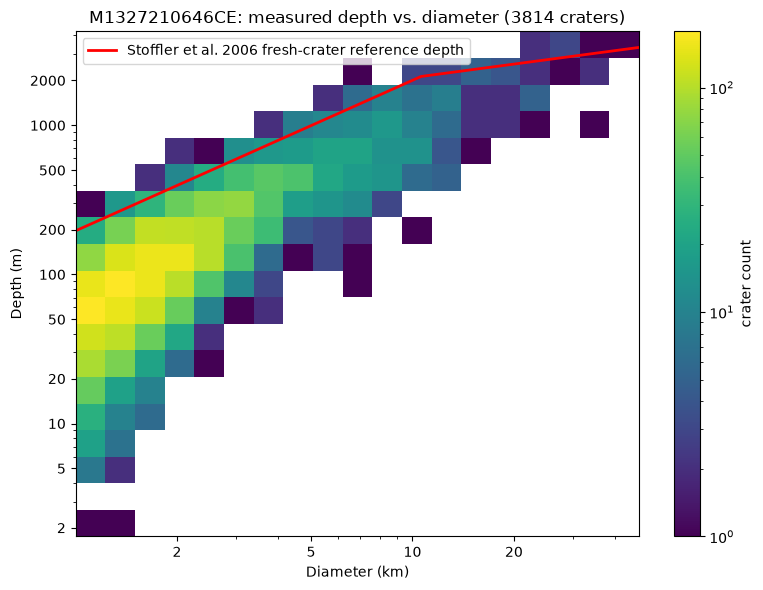

In [5]:
diameters_km = graded_view["diameter_km"].to_numpy()
depths_m = graded_view["depth_m"].to_numpy()

positive_depth = depths_m > 0
n_nonpositive = (~positive_depth).sum()
if n_nonpositive:
    print(f"Dropping {n_nonpositive} crater(s) with depth_m <= 0 -- can't place on a log depth axis")
diameters_km = diameters_km[positive_depth]
depths_m = depths_m[positive_depth]

diameter_bins = np.logspace(np.log10(diameters_km.min()), np.log10(diameters_km.max()), 20)
depth_bins = np.logspace(np.log10(depths_m.min()), np.log10(depths_m.max()), 20)

fig, ax = plt.subplots(figsize=(8, 6))
_, _, _, hist_image = ax.hist2d(
    diameters_km, depths_m, bins=[diameter_bins, depth_bins], cmap="viridis", norm=matplotlib.colors.LogNorm()
)
fig.colorbar(hist_image, ax=ax, label="crater count")

d_range_km = np.logspace(np.log10(diameters_km.min()), np.log10(diameters_km.max()), 200)
ax.plot(
    d_range_km,
    crater_depth.stoffler_fresh_depth_km(d_range_km) * 1000.0,
    color="red",
    linewidth=2.0,
    label="Stoffler et al. 2006 fresh-crater reference depth",
)
ax.set_xscale("log")
ax.set_yscale("log")
# Plain-number tick labels (not scientific notation), at a fixed 1/2/5-per-decade cadence, with
# minor-tick labels turned off -- the default log-axis locator/formatter packs in enough
# scientific-notation minor ticks (2x10^0, 3x10^0, 4x10^0, ...) over this data's < 2-decade range
# to visibly collide with each other.
for axis in (ax.xaxis, ax.yaxis):
    axis.set_major_locator(matplotlib.ticker.LogLocator(base=10.0, subs=(1.0, 2.0, 5.0)))
    axis.set_major_formatter(matplotlib.ticker.ScalarFormatter())
    axis.set_minor_formatter(matplotlib.ticker.NullFormatter())
ax.set_xlabel("Diameter (km)")
ax.set_ylabel("Depth (m)")
ax.set_title(f"{entry.edr_product}: measured depth vs. diameter ({len(graded_view)} craters)")
ax.legend()
fig.tight_layout()